# Sentiment Analysis using LSTM and GRU
**Dataset:** IMDB Movie Reviews (from Kaggle)  
**Models:** LSTM | GRU  
**Task:** Binary Sentiment Classification (Positive / Negative)

## 1. Dataset
https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

The dataset contains **50,000 movie reviews** labeled as `positive` or `negative`.

## 2. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


## 3. Load and Explore the Dataset

In [4]:
# Load the dataset
df = pd.read_csv("C:\\VSC\\IMDB Dataset.csv")

print("Shape:", df.shape)
df.head(5)

Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Label distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


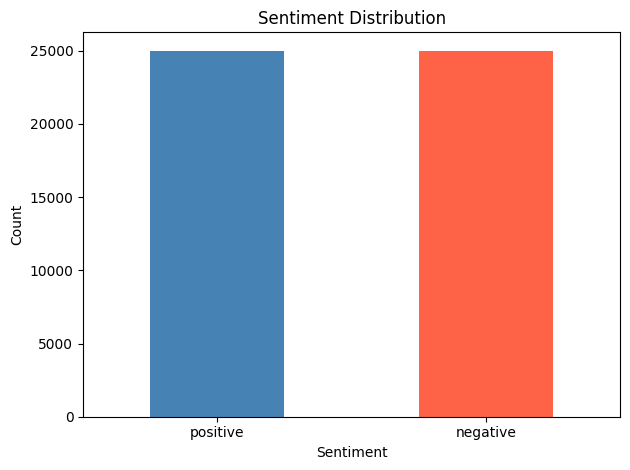

In [4]:
# Check class distribution
print("Label distribution:")
print(df['sentiment'].value_counts())

# Visualize
df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [5]:
def clean_text(text):
    """Remove HTML tags, special characters, and convert to lowercase."""
    text = re.sub(r'<.*?>', '', text)          # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # keep only letters
    text = text.lower().strip()                 # lowercase
    return text

# Apply cleaning
df['clean_review'] = df['review'].apply(clean_text)

# Encode labels: positive=1, negative=0
df['label'] = (df['sentiment'] == 'positive').astype(int)

print("Sample cleaned review:")
print(df['clean_review'][0][:200])

Sample cleaned review:
one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its bru


In [6]:
# Hyperparameters
VOCAB_SIZE    = 10000   
MAX_LEN       = 150    
EMBEDDING_DIM = 64 
BATCH_SIZE    = 128
EPOCHS        = 5

# Tokenization
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_review'])

sequences = tokenizer.texts_to_sequences(df['clean_review'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 150)
y shape: (50000,)


In [7]:
# Split: 70% train | 15% validation | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test:       {X_test.shape[0]} samples")

Train:      35000 samples
Validation: 7500 samples
Test:       7500 samples


## 5. Build the LSTM Model

In [8]:
def build_lstm_model():
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

c:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

print("Training LSTM model...")
start = time.time()

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

lstm_time = time.time() - start
print(f"\nLSTM training time: {lstm_time:.1f} seconds")

Training LSTM model...
Epoch 1/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 64s 218ms/step - accuracy: 0.6413 - loss: 0.6183 - val_accuracy: 0.7655 - val_loss: 0.5269
Epoch 2/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 65s 236ms/step - accuracy: 0.6512 - loss: 0.6306 - val_accuracy: 0.6541 - val_loss: 0.6270
Epoch 3/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 60s 220ms/step - accuracy: 0.7667 - loss: 0.5090 - val_accuracy: 0.8236 - val_loss: 0.3960
Epoch 4/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 94s 262ms/step - accuracy: 0.8629 - loss: 0.3447 - val_accuracy: 0.8544 - val_loss: 0.3432
Epoch 5/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 68s 247ms/step - accuracy: 0.8960 - loss: 0.2773 - val_accuracy: 0.8561 - val_loss: 0.3484

LSTM training time: 350.7 seconds


## 6. Build the GRU Model

In [10]:
def build_gru_model():
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
        Bidirectional(GRU(64, return_sequences=True)),
        Dropout(0.3),
        GRU(32),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

gru_model = build_gru_model()
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
print("Training GRU model...")
start = time.time()

gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

gru_time = time.time() - start
print(f"\nGRU training time: {gru_time:.1f} seconds")

Training GRU model...
Epoch 1/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 65s 237ms/step - accuracy: 0.8187 - loss: 0.4169 - val_accuracy: 0.8383 - val_loss: 0.3684
Epoch 2/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 55s 200ms/step - accuracy: 0.8722 - loss: 0.3147 - val_accuracy: 0.8528 - val_loss: 0.3429
Epoch 3/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 58s 211ms/step - accuracy: 0.9033 - loss: 0.2482 - val_accuracy: 0.8577 - val_loss: 0.3438
Epoch 4/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 59s 214ms/step - accuracy: 0.9252 - loss: 0.2044 - val_accuracy: 0.8661 - val_loss: 0.3426
Epoch 5/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 60s 219ms/step - accuracy: 0.9437 - loss: 0.1589 - val_accuracy: 0.8509 - val_loss: 0.4203

GRU training time: 296.1 seconds


## 7. Evaluate Both Models

In [19]:
# Test set evaluation
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
gru_loss,  gru_acc  = gru_model.evaluate(X_test, y_test, verbose=0)

print("=" * 40)
print(f"LSTM  -> Accuracy: {lstm_acc:.4f} | Loss: {lstm_loss:.4f} | Time: {lstm_time:.1f}s")
print(f"GRU   -> Accuracy: {gru_acc:.4f}  | Loss: {gru_loss:.4f}  | Time: {gru_time:.1f}s")
print("=" * 40)

LSTM  -> Accuracy: 0.8577 | Loss: 0.3347 | Time: 350.7s
GRU   -> Accuracy: 0.8605  | Loss: 0.3365  | Time: 296.1s


In [20]:
# Classification reports
y_pred_lstm = (lstm_model.predict(X_test) > 0.5).astype(int).flatten()
y_pred_gru  = (gru_model.predict(X_test)  > 0.5).astype(int).flatten()

print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

print("GRU Classification Report:")
print(classification_report(y_test, y_pred_gru, target_names=['Negative', 'Positive']))

235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step
LSTM Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.83      0.85      3722
    Positive       0.84      0.89      0.86      3778

    accuracy                           0.86      7500
   macro avg       0.86      0.86      0.86      7500
weighted avg       0.86      0.86      0.86      7500

GRU Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.87      0.86      3722
    Positive       0.87      0.85      0.86      3778

    accuracy                           0.86      7500
   macro avg       0.86      0.86      0.86      7500
weighted avg       0.86      0.86      0.86      7500



## 8. Visualize Training History

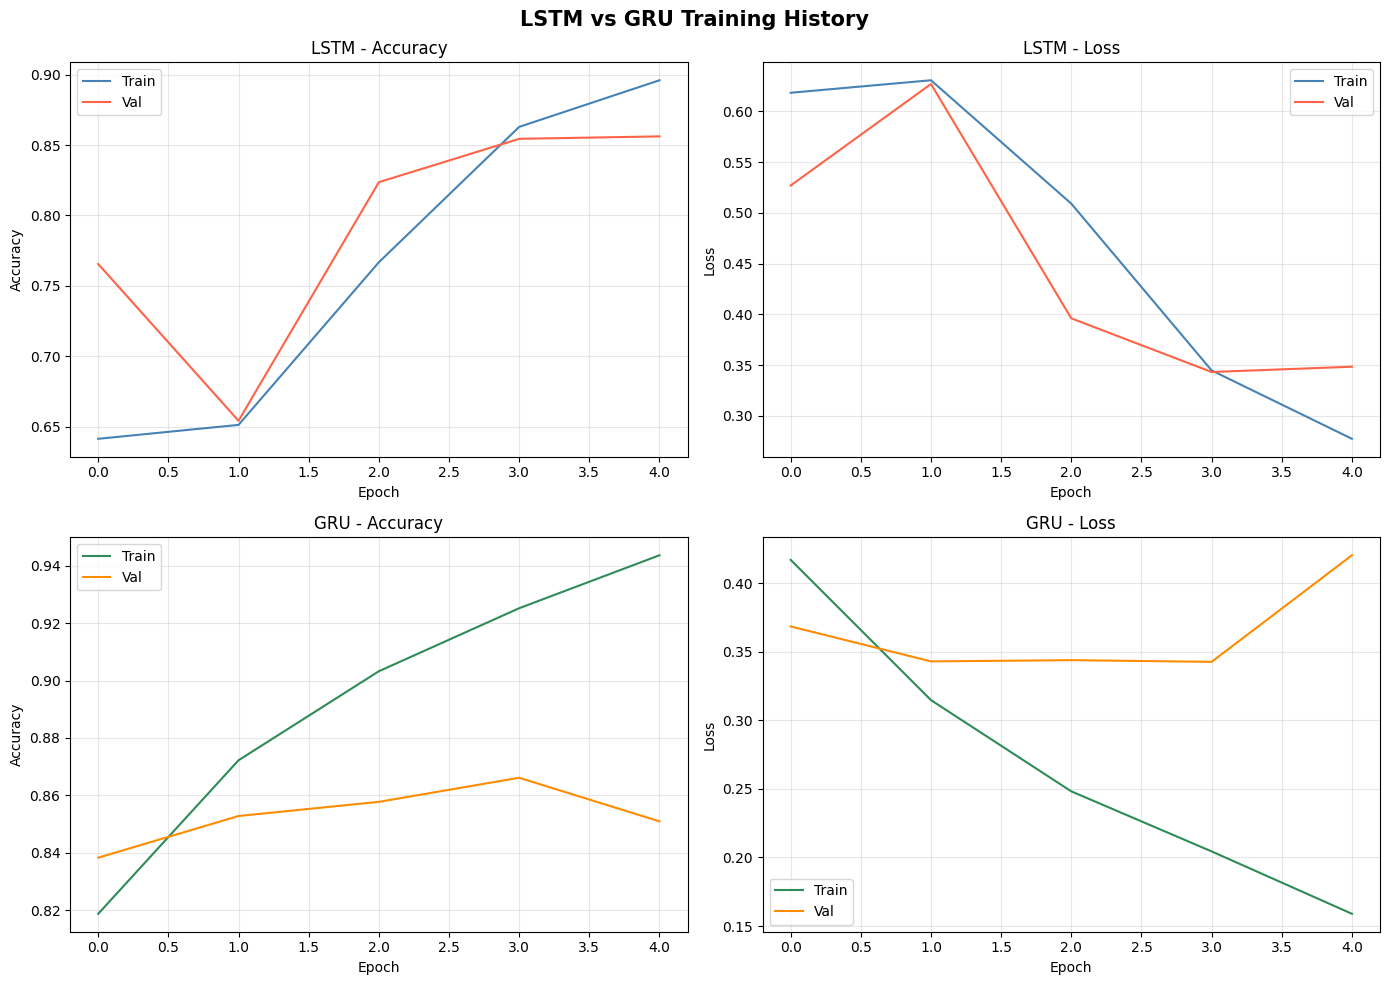

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LSTM Accuracy
axes[0, 0].plot(lstm_history.history['accuracy'],     label='Train', color='steelblue')
axes[0, 0].plot(lstm_history.history['val_accuracy'], label='Val',   color='tomato')
axes[0, 0].set_title('LSTM - Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# LSTM Loss
axes[0, 1].plot(lstm_history.history['loss'],     label='Train', color='steelblue')
axes[0, 1].plot(lstm_history.history['val_loss'], label='Val',   color='tomato')
axes[0, 1].set_title('LSTM - Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# GRU Accuracy
axes[1, 0].plot(gru_history.history['accuracy'],     label='Train', color='seagreen')
axes[1, 0].plot(gru_history.history['val_accuracy'], label='Val',   color='darkorange')
axes[1, 0].set_title('GRU - Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# GRU Loss
axes[1, 1].plot(gru_history.history['loss'],     label='Train', color='seagreen')
axes[1, 1].plot(gru_history.history['val_loss'], label='Val',   color='darkorange')
axes[1, 1].set_title('GRU - Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('LSTM vs GRU Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

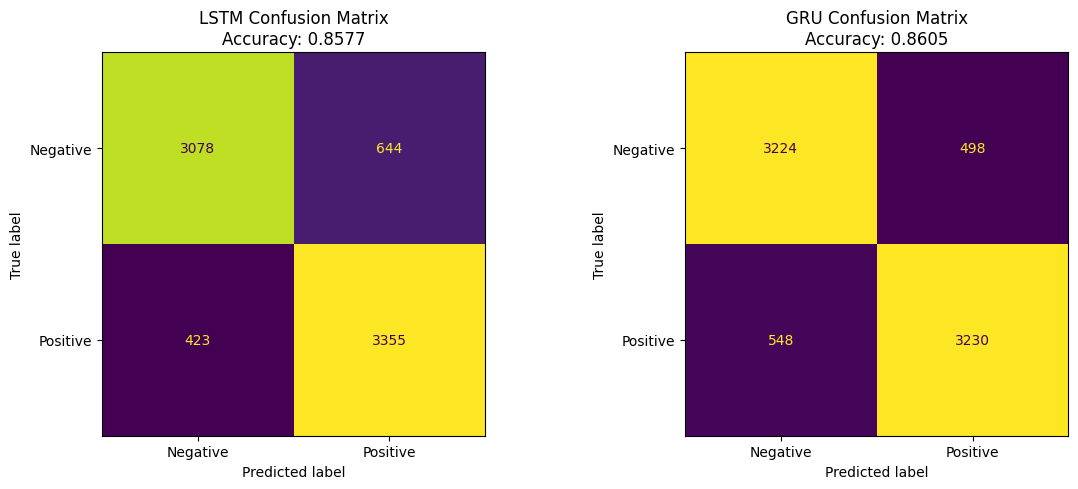

In [27]:
# Confusion Matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
cm_gru  = confusion_matrix(y_test, y_pred_gru)

ConfusionMatrixDisplay(cm_lstm, display_labels=['Negative', 'Positive']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'LSTM Confusion Matrix\nAccuracy: {lstm_acc:.4f}')

ConfusionMatrixDisplay(cm_gru, display_labels=['Negative', 'Positive']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'GRU Confusion Matrix\nAccuracy: {gru_acc:.4f}')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Model Comparison Summary

In [31]:
summary_data = {
    'Model':          ['LSTM', 'GRU'],
    'Test Accuracy':  [f'{lstm_acc:.4f}', f'{gru_acc:.4f}'],
    'Test Loss':      [f'{lstm_loss:.4f}', f'{gru_loss:.4f}'],
    'Training Time':  [f'{lstm_time:.1f}s', f'{gru_time:.1f}s'],
    'Parameters':     [
        lstm_model.count_params(),
        gru_model.count_params()
    ]
}

comparison_df = pd.DataFrame(summary_data)
print(comparison_df.to_string(index=False))

Model Test Accuracy Test Loss Training Time  Parameters
 LSTM        0.8577    0.3347        350.7s      728833
  GRU        0.8605    0.3365        296.1s      707649


## 10. Predict on New Reviews

In [32]:
def predict_sentiment(review_text, model, label='Model'):
    cleaned  = clean_text(review_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')
    prob     = model.predict(padded, verbose=0)[0][0]
    sentiment = 'Positive' if prob >= 0.5 else 'Negative'
    print(f"[{label}] Sentiment: {sentiment} (confidence: {prob:.4f})")

# Test examples
reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat.",
    "Terrible movie. Complete waste of time. The plot made no sense and the acting was awful.",
    "It was okay. Some parts were good but overall I found it pretty average."
]

for review in reviews:
    print(f"Review: {review[:60]}...")
    predict_sentiment(review, lstm_model, 'LSTM')
    predict_sentiment(review, gru_model,  'GRU')
    print()

Review: This movie was absolutely fantastic! The acting was superb a...
[LSTM] Sentiment: Positive (confidence: 0.9499)
[GRU] Sentiment: Positive (confidence: 0.9954)

Review: Terrible movie. Complete waste of time. The plot made no sen...
[LSTM] Sentiment: Negative (confidence: 0.0277)
[GRU] Sentiment: Negative (confidence: 0.0058)

Review: It was okay. Some parts were good but overall I found it pre...
[LSTM] Sentiment: Positive (confidence: 0.5571)
[GRU] Sentiment: Positive (confidence: 0.9836)

